## Data Understanding


In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df= pd.read_csv("data_icu.csv")

print("Dataset berhasil dimuat")

Dataset berhasil dimuat


In [132]:
print("Ukuran dataset:")
print(df.shape)

print("\n10 baris pertama:")
display(df.head(10))

print("\nInformasi dataset:")
df.info()

Ukuran dataset:
(4580, 16)

10 baris pertama:


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1
5,ICU_02045,82,0,23.5,89.4,122.8,64.7,34.2,100.0,220.5,1.83,1.00,6,0,3,0
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
7,ICU_05817,65,1,28.6,54.1,114.3,61.0,20.8,97.9,221.8,0.49,7.63,19,0,5,1
8,ICU_00734,80,0,24.1,62.6,123.0,76.4,15.6,100.0,135.4,0.42,6.69,3,1,1,0
9,ICU_03391,47,1,12.1,77.5,158.0,69.0,27.8,100.0,185.9,0.30,13.70,20,0,1,1



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   object 
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  s

In [133]:
# df.describe(
#     percentiles=[
#         0.25,
#         0.50,
#         0.75,
#         0.85,
#         0.90,
#         0.95,
#         0.97,
#         0.98,
#         0.99
#     ]
# ).T

In [134]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


In [135]:
missing = pd.DataFrame({
    "jumlah_missing": df.isna().sum(),
    "persentase_missing": (df.isna().mean() * 100).round(2).astype(str) + '%'
})

missing = missing.sort_values(
    by="jumlah_missing",
    ascending=False
)

display(missing)


,jumlah_missing,persentase_missing
wbc_count,808,17.64%
creatinine,641,14.0%
bmi,621,13.56%
oxygen_saturation,603,13.17%
respiratory_rate,575,12.55%
gender,0,0.0%
age,0,0.0%
patient_id,0,0.0%
diastolic_bp,0,0.0%
systolic_bp,0,0.0%


In [136]:
df_missing = df[df.isna().any(axis=1)]

print("Jumlah pasien yang memiliki minimal satu missing value:")
print(len(df_missing))

display(df_missing.head(15))

Jumlah pasien yang memiliki minimal satu missing value:
808


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
17,ICU_03155,32,0,NaN,91.1,123.6,83.9,NaN,NaN,163.4,NaN,NaN,15,1,0,0
20,ICU_04227,69,0,NaN,77.4,149.2,91.3,NaN,NaN,133.6,NaN,NaN,4,1,5,1
21,ICU_02534,54,1,NaN,126.6,172.4,56.1,NaN,NaN,75.4,NaN,NaN,11,1,2,1
22,ICU_00433,74,0,NaN,105.8,130.5,61.5,NaN,NaN,157.5,NaN,NaN,17,1,4,1
23,ICU_02454,74,1,24.9,86.7,181.7,111.9,19.9,86.9,199.6,0.97,NaN,7,1,2,0
28,ICU_04704,72,0,NaN,103.7,100.4,75.3,19.4,92.9,266.6,NaN,NaN,22,0,1,1
31,ICU_01850,50,1,NaN,70.7,101.9,48.4,NaN,NaN,145.8,NaN,NaN,0,1,4,0
38,ICU_01500,76,0,34.8,45.1,132.5,79.9,27.0,92.2,144.3,0.30,NaN,23,1,3,0
41,ICU_02726,80,0,NaN,98.8,134.3,76.6,NaN,NaN,102.8,NaN,NaN,2,0,1,1


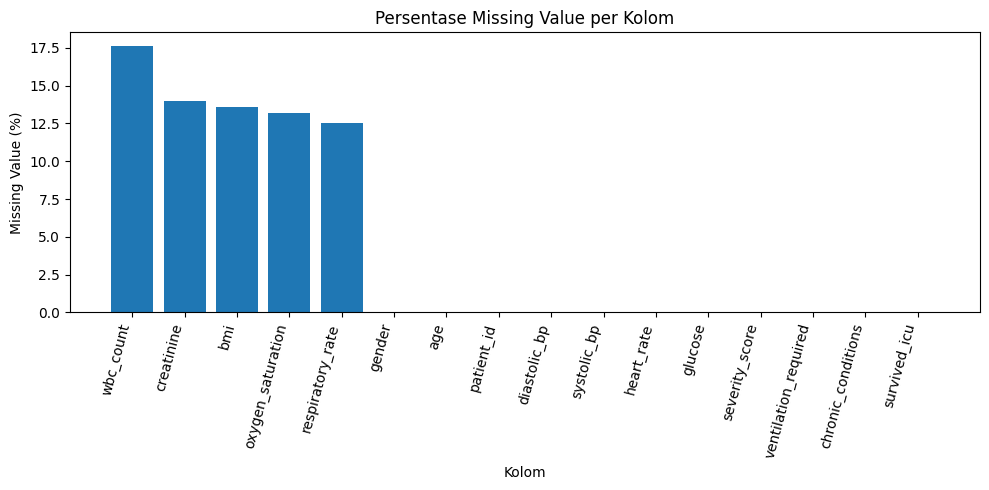

In [137]:
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    missing_pct.index,
    missing_pct.values
)

plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing Value (%)")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

In [138]:
duplicate_full = df.duplicated().sum()

print("Jumlah duplikat seluruh kolom:", duplicate_full)

Jumlah duplikat seluruh kolom: 0


In [139]:
fitur_tanpa_id = df.drop(columns=["patient_id"])

hidden_duplicate = fitur_tanpa_id.duplicated(keep=False)

print(
    "Jumlah baris yang terlibat duplikat tersembunyi:",
    hidden_duplicate.sum()
)

print(
    "Jumlah duplikat tambahan:",
    fitur_tanpa_id.duplicated(keep="first").sum()
)

Jumlah baris yang terlibat duplikat tersembunyi: 116
Jumlah duplikat tambahan: 58


In [140]:
data_duplicate = df[hidden_duplicate].copy()

display(
    data_duplicate.sort_values(
        by=list(df.columns.drop("patient_id"))
    ).head(116)
)



,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
2820,ICU_05907,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
3378,ICU_00013,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
4547,ICU_DUP_0030,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
1965,ICU_02280,30,0,27.2,109.4,106.5,96.2,10.3,92.4,148.5,1.10,17.42,18,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,ICU_DUP_0029,95,1,20.7,71.0,66.4,63.8,13.4,91.8,204.5,3.33,22.91,22,0,5,0
3349,ICU_DUP_0008,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
4168,ICU_03982,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
766,ICU_DUP_0015,95,1,32.9,64.5,195.2,69.6,19.6,85.7,250.1,0.96,43.03,15,1,1,0


In [141]:
print("Jumlah patient_id duplikat:")
print(df["patient_id"].duplicated().sum())

Jumlah patient_id duplikat:
0


In [142]:
id_normal = df["patient_id"].str.match(r"^ICU_\d{5}$")

id_duplicate_style = df["patient_id"].str.match(
    r"^ICU_DUP_\d{4}$"
)

id_invalid = ~(id_normal | id_duplicate_style)

print("ID normal        :", id_normal.sum())
print("ID pola DUP      :", id_duplicate_style.sum())
print("ID tidak dikenal :", id_invalid.sum())

ID normal        : 4500
ID pola DUP      : 80
ID tidak dikenal : 0


In [143]:
display(
    df[df["patient_id"].str.startswith("ICU_DUP_")].head(15)
)

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
34,ICU_DUP_0018,43,1,21.4,87.3,139.4,98.1,11.2,85.5,262.5,0.36,1.08,10,0,1,1
54,ICU_DUP_0061,53,1,32.0,94.1,97.7,50.0,27.1,96.2,69.2,3.04,1.00,23,0,0,1
82,ICU_DUP_0043,58,1,23.2,116.6,129.2,82.1,8.3,90.9,92.5,0.31,11.28,23,1,1,0
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
396,ICU_DUP_0028,71,0,26.4,95.8,155.4,89.7,18.4,89.8,122.7,0.32,4.09,8,0,3,0
410,ICU_DUP_0047,79,0,22.7,105.1,112.2,87.7,12.7,100.0,222.2,0.33,10.89,7,0,0,0
416,ICU_DUP_0074,80,1,28.4,102.1,189.0,130.0,21.7,95.0,96.2,0.30,6.14,14,0,1,1
418,ICU_DUP_0020,51,0,NaN,53.2,106.6,63.6,NaN,NaN,236.5,NaN,NaN,0,0,3,0
463,ICU_DUP_0079,57,0,NaN,78.8,91.4,48.0,24.7,95.5,75.9,NaN,NaN,16,0,3,1
474,ICU_DUP_0013,39,0,21.0,104.0,105.8,67.2,23.0,99.3,119.6,0.30,1.00,23,0,0,1


In [144]:
kolom_kategori = [
    "gender",
    "ventilation_required",
    "survived_icu",
    "severity_score",
    "chronic_conditions"
]

for kolom in kolom_kategori:
    print(f"\n{kolom}")
    print("Nilai unik :", sorted(df[kolom].dropna().unique()))
    print("Jumlah unik:", df[kolom].nunique())


gender
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

ventilation_required
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

survived_icu
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

severity_score
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Jumlah unik: 25

chronic_conditions
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Jumlah unik: 6


In [145]:
continuous_features = [
    "age",
    "bmi",
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "respiratory_rate",
    "oxygen_saturation",
    "glucose",
    "creatinine",
    "wbc_count"
]

In [146]:
hasil_outlier = []

for kolom in continuous_features:

    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = (
        (df[kolom] < lower_bound) |
        (df[kolom] > upper_bound)
    )

    hasil_outlier.append({
        "fitur": kolom,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "jumlah_outlier": outlier.sum(),
        "persentase": round(outlier.mean() * 100, 2)
    })

outlier_table = pd.DataFrame(hasil_outlier)

display(outlier_table)

,fitur,lower_bound,upper_bound,jumlah_outlier,persentase
0,age,15.50000,107.50000,0,0.00
1,bmi,6.45000,46.85000,47,1.03
2,heart_rate,29.20000,148.40000,106,2.31
3,systolic_bp,38.30000,199.10000,101,2.21
4,diastolic_bp,23.80000,119.80000,16,0.35
5,respiratory_rate,1.60000,34.40000,8,0.17
6,oxygen_saturation,81.65000,108.45000,15,0.33
7,glucose,-26.30000,309.90000,95,2.07
8,creatinine,-1.72500,3.83500,198,4.32
9,wbc_count,-14.32375,31.44625,163,3.56


In [147]:
logical_check = {
    "age < 0":
        (df["age"] < 0).sum(),

    "bmi <= 0":
        (df["bmi"] <= 0).sum(),

    "heart_rate <= 0":
        (df["heart_rate"] <= 0).sum(),

    "systolic_bp <= 0":
        (df["systolic_bp"] <= 0).sum(),

    "diastolic_bp <= 0":
        (df["diastolic_bp"] <= 0).sum(),

    "systolic < diastolic":
        (df["systolic_bp"] < df["diastolic_bp"]).sum(),

    "respiratory_rate <= 0":
        (df["respiratory_rate"] <= 0).sum(),

    "oxygen_saturation di luar 0-100":
        (
            (df["oxygen_saturation"] < 0) |
            (df["oxygen_saturation"] > 100)
        ).sum(),

    "glucose <= 0":
        (df["glucose"] <= 0).sum(),

    "creatinine < 0":
        (df["creatinine"] < 0).sum(),

    "wbc_count < 0":
        (df["wbc_count"] < 0).sum()
}

logical_check = pd.Series(
    logical_check,
    name="jumlah"
)

display(logical_check)

,jumlah
age < 0,0
bmi <= 0,0
heart_rate <= 0,0
systolic_bp <= 0,0
diastolic_bp <= 0,0
systolic < diastolic,344
respiratory_rate <= 0,0
oxygen_saturation di luar 0-100,0
glucose <= 0,0
creatinine < 0,0


In [148]:
bp_anomali = df[
    df["systolic_bp"] < df["diastolic_bp"]
]

display(
    bp_anomali[
        [
            "patient_id",
            "systolic_bp",
            "diastolic_bp"
        ]
    ].head(20)
)

,patient_id,systolic_bp,diastolic_bp
12,ICU_03249,95.9,115.5
13,ICU_03997,68.7,80.4
65,ICU_04279,60.1,72.7
71,ICU_04038,83.3,99.0
97,ICU_02256,93.1,99.7
104,ICU_00764,81.0,89.3
118,ICU_05584,69.6,73.8
119,ICU_02566,60.0,88.8
133,ICU_00587,76.6,103.4
142,ICU_00290,76.7,94.3


In [149]:
target_count = df["survived_icu"].value_counts().sort_index()

target_percentage = (
    df["survived_icu"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "jumlah": target_count,
    "persentase": target_percentage.round(2).astype(str) + '%'
})

display(target_summary)

,jumlah,persentase
survived_icu,,
0,1632,35.63%
1,2948,64.37%


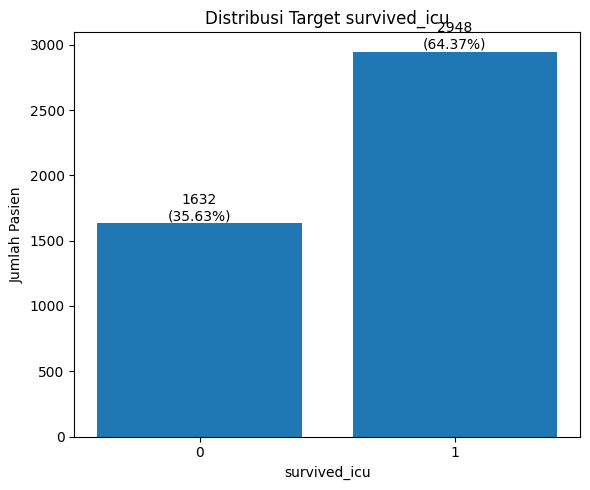

In [150]:
plt.figure(figsize=(6, 5))

bars = plt.bar(
    target_count.index.astype(str),
    target_count.values
)

plt.title("Distribusi Target survived_icu")
plt.xlabel("survived_icu")
plt.ylabel("Jumlah Pasien")

for bar, jumlah, persen in zip(
    bars,
    target_count.values,
    target_percentage.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{jumlah}\n({persen:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

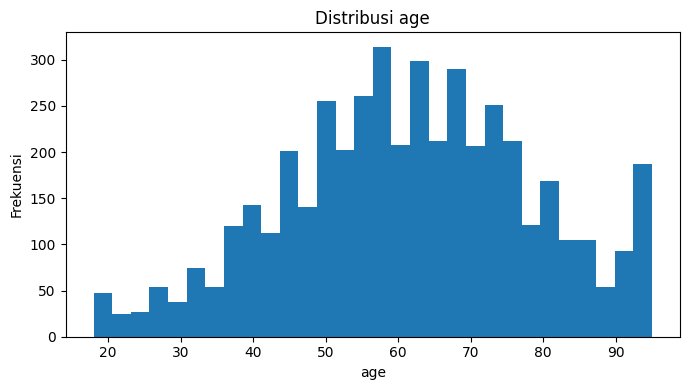

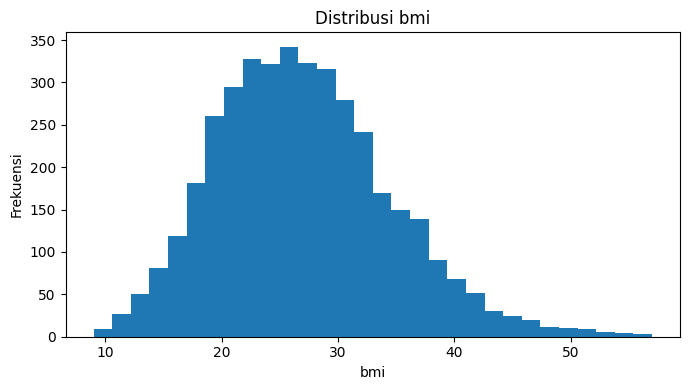

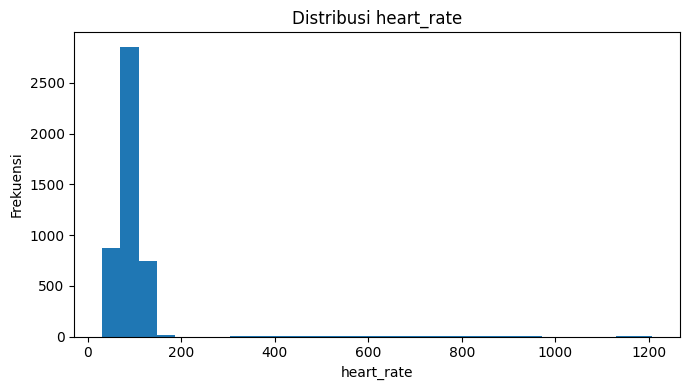

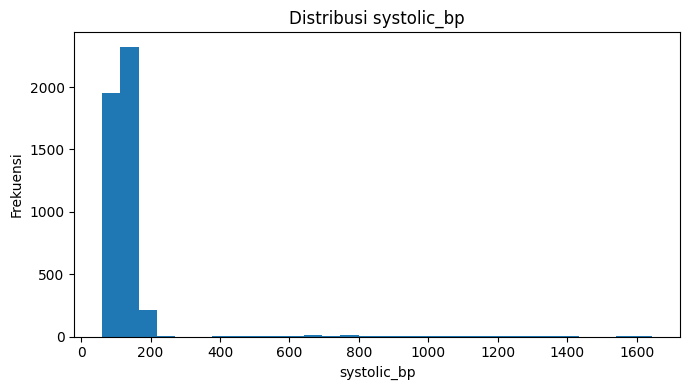

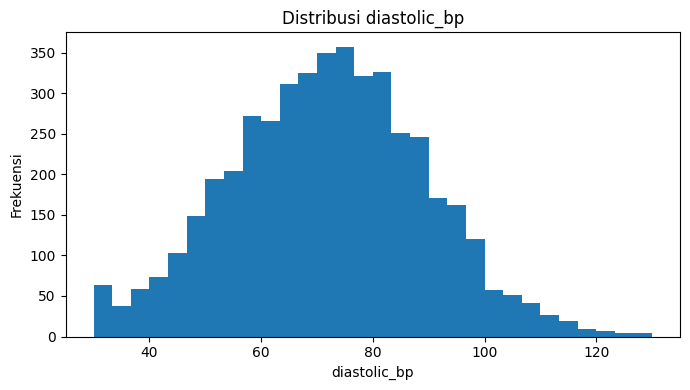

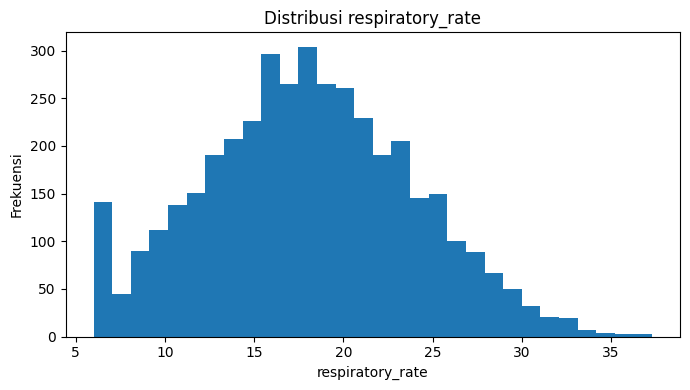

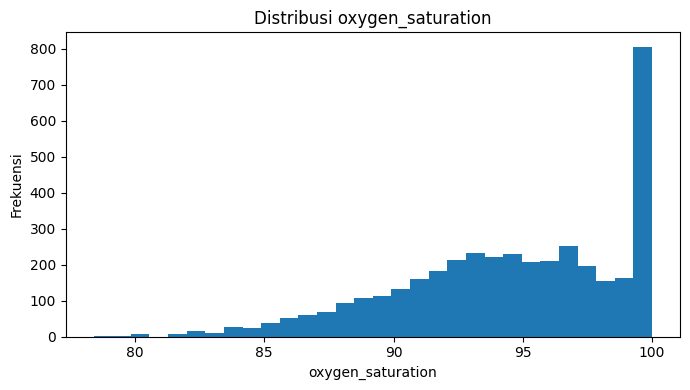

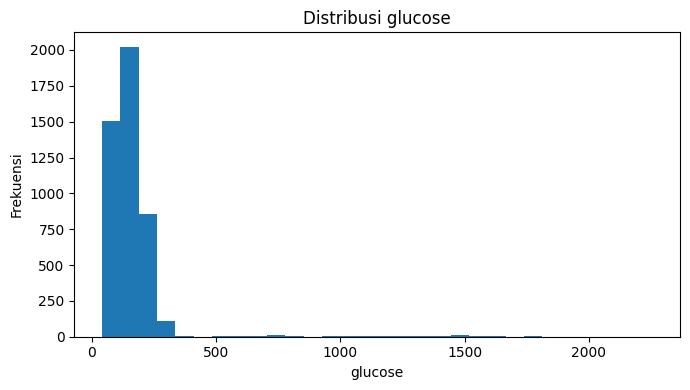

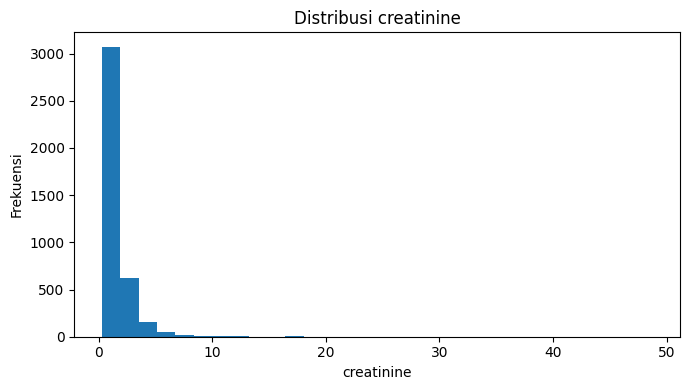

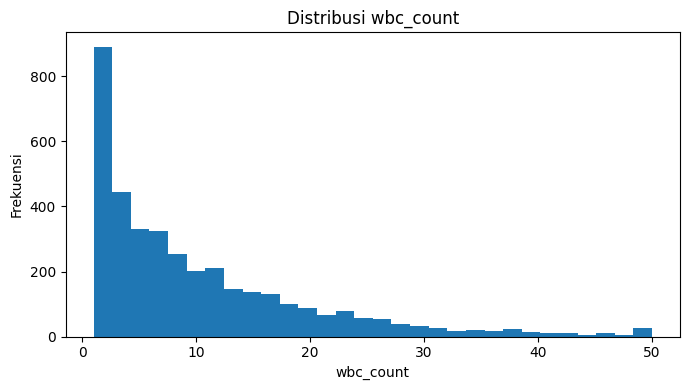

In [151]:
for col in continuous_features:

    plt.figure(
        figsize=(7, 4)
    )

    plt.hist(
        df[col].dropna(),
        bins=30
    )

    plt.title(
        f"Distribusi {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

## Data Cleaning


In [152]:
df_raw = df.copy()

df_clean = df.copy()

print("Ukuran data awal:", df_raw.shape)

Ukuran data awal: (4580, 16)


In [153]:
non_id_cols = [
    col for col in df_clean.columns
    if col != "patient_id"
]

print("Jumlah fitur pembanding:", len(non_id_cols))

Jumlah fitur pembanding: 15


In [154]:
df_clean["_is_dup_id"] = (
    df_clean["patient_id"]
    .str.startswith("ICU_DUP_")
    .astype(int)
)

print(
    df_clean["_is_dup_id"]
    .value_counts()
)

_is_dup_id
0    4500
1      80
Name: count, dtype: int64


In [155]:
all_duplicate_mask = (
    df_clean
    .duplicated(
        subset=non_id_cols,
        keep=False
    )
)

print(
    "Seluruh baris yang terlibat duplicate:",
    all_duplicate_mask.sum()
)

Seluruh baris yang terlibat duplicate: 116


In [156]:
df_clean = (
    df_clean
    .sort_values("_is_dup_id")
    .reset_index(drop=True)
)

In [157]:
duplicate_mask = (
    df_clean
    .duplicated(
        subset=non_id_cols,
        keep="first"
    )
)

In [158]:
n_removed_duplicate = (
    duplicate_mask.sum()
)

print(
    "Duplicate tambahan yang dibuang:",
    n_removed_duplicate
)

Duplicate tambahan yang dibuang: 58


In [159]:
df_clean = (
    df_clean.loc[
        ~duplicate_mask
    ]
    .copy()
)

df_clean = (
    df_clean
    .drop(
        columns="_is_dup_id"
    )
    .reset_index(drop=True)
)

print(
    "Ukuran setelah duplicate dibuang:",
    df_clean.shape
)

Ukuran setelah duplicate dibuang: (4522, 16)


In [160]:
# df_clean.describe(percentiles=[
#         0.25,
#         0.50,
#         0.75,
#         0.85,
#         0.90,
#         0.95,
#         0.97,
#         0.98,
#         0.99
#     ]).T

In [161]:
print(
    "HR tertinggi <=250:",
    df_clean.loc[
        df_clean["heart_rate"] <= 250,
        "heart_rate"
    ].max()
)

print(
    "HR terendah >250:",
    df_clean.loc[
        df_clean["heart_rate"] > 250,
        "heart_rate"
    ].min()
)

print(
    "\nSBP tertinggi <=300:",
    df_clean.loc[
        df_clean["systolic_bp"] <= 300,
        "systolic_bp"
    ].max()
)

print(
    "SBP terendah >300:",
    df_clean.loc[
        df_clean["systolic_bp"] > 300,
        "systolic_bp"
    ].min()
)

HR tertinggi <=250: 169.2
HR terendah >250: 314.5521893515285

SBP tertinggi <=300: 220.0
SBP terendah >300: 381.7834844177826


In [162]:
extreme_hr = df_clean["heart_rate"] > 250
extreme_sbp = df_clean["systolic_bp"] > 300

print("HR ekstrem :", extreme_hr.sum())
print("SBP ekstrem:", extreme_sbp.sum())

print(
    "Keduanya:",
    (extreme_hr & extreme_sbp).sum()
)

HR ekstrem : 92
SBP ekstrem: 92
Keduanya: 92


In [163]:
extreme_both = (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
)

fitur_cek = [
    "glucose",
    "creatinine"
]

print("KELOMPOK HR + SBP EKSTREM")

display(
    df_clean.loc[
        extreme_both,
        fitur_cek
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

print("DI LUAR KELOMPOK HR + SBP EKSTREM")

display(
    df_clean.loc[
        ~extreme_both,
        fitur_cek
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)


KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,92.0,1073.548502,453.166076,208.986544,734.316771,1070.096463,1427.126426,1598.785984,1761.433983,2132.079958,2256.210085
creatinine,77.0,7.969650,7.797991,1.512089,2.962469,5.233237,8.701402,17.111897,22.721197,34.413958,48.737770


DI LUAR KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,4430.0,140.704831,58.375889,40.0,98.90,139.35,181.00,216.400,241.81,279.1420,364.70
creatinine,3804.0,1.238680,1.145799,0.3,0.36,0.87,1.67,2.707,3.51,5.5288,10.71


In [164]:
extreme_both = (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
)

df_92_extreme = (
    df_clean.loc[extreme_both]
    .copy()
)

print(
    "Jumlah pasien ekstrem:",
    len(df_92_extreme)
)

Jumlah pasien ekstrem: 92


In [165]:
display(
    df_92_extreme
)

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
18,ICU_04554,60,1,22.9,732.349877,683.200398,106.8,12.6,100.0,799.805198,17.733658,10.89,3,0,0,1
40,ICU_04740,71,0,33.9,578.557000,662.838612,81.1,8.3,95.5,842.695919,1.512089,1.94,17,0,1,0
88,ICU_04454,84,1,NaN,336.433123,1211.301560,62.5,NaN,NaN,777.201735,NaN,NaN,21,1,1,0
106,ICU_00388,79,0,NaN,931.597346,1063.461244,90.5,NaN,NaN,1222.563969,NaN,NaN,11,0,2,0
180,ICU_03885,71,1,24.3,598.125737,892.574383,40.6,14.5,85.4,1252.147077,3.715228,1.00,15,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4176,ICU_00849,52,0,20.0,526.988469,795.639845,91.6,12.3,97.3,1586.195179,25.805722,15.51,15,0,0,1
4202,ICU_04257,87,0,22.1,881.099401,941.484668,58.3,13.7,93.1,390.556783,1.887898,7.29,4,1,0,1
4356,ICU_04770,62,1,25.3,371.635025,1216.453190,87.4,6.0,100.0,1346.270817,13.941673,12.43,17,1,2,1
4398,ICU_01723,73,1,42.5,617.989920,1032.009201,59.1,21.3,89.1,1199.507700,5.078344,9.12,13,1,1,1


In [166]:
extreme_corrupt = (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
)

display(
    df_clean.loc[
        extreme_corrupt,
        [
            "patient_id",
            "heart_rate",
            "systolic_bp",
            "glucose",
            "creatinine"
        ]
    ].head(10)
)

,patient_id,heart_rate,systolic_bp,glucose,creatinine
18,ICU_04554,732.349877,683.200398,799.805198,17.733658
40,ICU_04740,578.557000,662.838612,842.695919,1.512089
88,ICU_04454,336.433123,1211.301560,777.201735,NaN
106,ICU_00388,931.597346,1063.461244,1222.563969,NaN
180,ICU_03885,598.125737,892.574383,1252.147077,3.715228
321,ICU_03113,555.745107,718.239302,1258.922134,8.454028
360,ICU_03342,595.110975,1645.595945,381.136227,18.013604
380,ICU_05079,462.506770,1420.574368,1076.198408,4.049351
403,ICU_05950,314.552189,599.585104,1480.513181,29.044803
424,ICU_02856,843.637490,1104.353853,604.804650,NaN


In [167]:
n_removed_extreme = extreme_corrupt.sum()

print(
    "Jumlah corrupted extreme rows:",
    n_removed_extreme
)

Jumlah corrupted extreme rows: 92


In [168]:
df_clean = df_clean.loc[
    ~extreme_corrupt
].copy()

print("Ukuran dataset setelah extreme corruption dibuang:")
print(df_clean.shape)

Ukuran dataset setelah extreme corruption dibuang:
(4430, 16)


In [169]:
display(
    df_clean[
        [
            "heart_rate",
            "systolic_bp",
            "diastolic_bp"
        ]
    ].agg(["min", "median", "max"])
)

,heart_rate,systolic_bp,diastolic_bp
min,30.0,60.0,30.00
median,88.4,117.6,72.15
max,169.2,220.0,130.00


In [170]:
bp_inconsistent = (
    df_clean["systolic_bp"]
    <
    df_clean["diastolic_bp"]
)

print(
    "Jumlah systolic < diastolic:",
    bp_inconsistent.sum()
)

Jumlah systolic < diastolic: 343


In [171]:
n_bp_corrected = bp_inconsistent.sum()

systolic_lama = df_clean.loc[
    bp_inconsistent,
    "systolic_bp"
].copy()

df_clean.loc[
    bp_inconsistent,
    "systolic_bp"
] = df_clean.loc[
    bp_inconsistent,
    "diastolic_bp"
].values

df_clean.loc[
    bp_inconsistent,
    "diastolic_bp"
] = systolic_lama.values

In [172]:
print(
    "Systolic < diastolic setelah perbaikan:",
    (
        df_clean["systolic_bp"]
        <
        df_clean["diastolic_bp"]
    ).sum()
)

Systolic < diastolic setelah perbaikan: 0


In [173]:
missing_cols = [
    "bmi",
    "respiratory_rate",
    "oxygen_saturation",
    "creatinine",
    "wbc_count"
]

missing_after_cleaning = pd.DataFrame({
    "jumlah_missing":
        df_clean[missing_cols].isna().sum(),

    "persentase_missing":
        (
            df_clean[missing_cols]
            .isna()
            .mean()
            * 100
        ).round(2)
})

display(missing_after_cleaning)

,jumlah_missing,persentase_missing
bmi,608,13.72
respiratory_rate,563,12.71
oxygen_saturation,590,13.32
creatinine,626,14.13
wbc_count,790,17.83


In [174]:
missing_pattern = (
    df_clean[missing_cols]
    .isna()
    .astype(int)
)

def nama_pola(row):

    kolom_missing = [
        col
        for col in missing_cols
        if row[col] == 1
    ]

    if len(kolom_missing) == 0:
        return "Tidak ada missing"

    return ", ".join(kolom_missing)


missing_pattern["pola"] = (
    missing_pattern.apply(
        nama_pola,
        axis=1
    )
)

display(
    missing_pattern["pola"]
    .value_counts()
    .rename("jumlah")
    .to_frame()
)

,jumlah
pola,
Tidak ada missing,3640
"bmi, respiratory_rate, oxygen_saturation, creatinine, wbc_count",563
wbc_count,164
"bmi, oxygen_saturation, creatinine, wbc_count",27
"bmi, creatinine, wbc_count",18
"creatinine, wbc_count",18


In [175]:
mask_5_missing = (
    df_clean["bmi"].isna()
    & df_clean["respiratory_rate"].isna()
    & df_clean["oxygen_saturation"].isna()
    & df_clean["creatinine"].isna()
    & df_clean["wbc_count"].isna()
)

print(
    "Jumlah pasien:",
    mask_5_missing.sum()
)

Jumlah pasien: 563


In [176]:
display(
    df_clean.loc[
        mask_5_missing,
        [
            "patient_id",
            "bmi",
            "respiratory_rate",
            "oxygen_saturation",
            "creatinine",
            "wbc_count"
        ]
    ].head(20)
)

,patient_id,bmi,respiratory_rate,oxygen_saturation,creatinine,wbc_count
21,ICU_03015,NaN,NaN,NaN,NaN,NaN
24,ICU_05550,NaN,NaN,NaN,NaN,NaN
33,ICU_05682,NaN,NaN,NaN,NaN,NaN
41,ICU_02322,NaN,NaN,NaN,NaN,NaN
42,ICU_00102,NaN,NaN,NaN,NaN,NaN
48,ICU_01798,NaN,NaN,NaN,NaN,NaN
51,ICU_04499,NaN,NaN,NaN,NaN,NaN
56,ICU_04381,NaN,NaN,NaN,NaN,NaN
65,ICU_01236,NaN,NaN,NaN,NaN,NaN
69,ICU_05320,NaN,NaN,NaN,NaN,NaN


In [177]:
total_removed = (
    n_removed_duplicate
    +
    n_removed_extreme
)

print("Total baris dibuang:", total_removed)

print(
    "Persentase:",
    round(
        total_removed
        / len(df_raw)
        * 100,
        2
    ),
    "%"
)

Total baris dibuang: 150
Persentase: 3.28 %


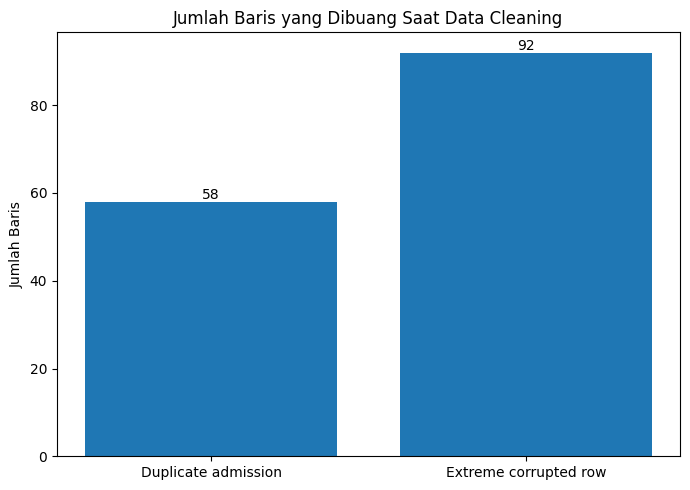

In [178]:
removed_rows = pd.Series({
    "Duplicate admission": n_removed_duplicate,
    "Extreme corrupted row": n_removed_extreme
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    removed_rows.index,
    removed_rows.values
)

plt.title(
    "Jumlah Baris yang Dibuang Saat Data Cleaning"
)

plt.ylabel("Jumlah Baris")

for bar, value in zip(
    bars,
    removed_rows.values
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [179]:
assert df_clean["patient_id"].is_unique

In [180]:
assert not df_clean.duplicated(
    subset=non_id_cols,
    keep=False
).any()

In [181]:
assert not (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
).any()

In [182]:
assert (
    df_clean["systolic_bp"]
    >=
    df_clean["diastolic_bp"]
).all()

In [183]:
assert set(
    df_clean["survived_icu"].unique()
).issubset({0, 1})

In [184]:
assert set(
    df_clean["gender"].unique()
).issubset({0, 1})

In [185]:
assert set(
    df_clean[
        "ventilation_required"
    ].unique()
).issubset({0, 1})

In [186]:
print(
    "Semua pemeriksaan cleaning berhasil."
)

Semua pemeriksaan cleaning berhasil.


In [187]:
cleaning_log = pd.DataFrame({
    "proses": [
        "Data awal",
        "Hapus duplicate ICU_DUP",
        "Hapus corrupted extreme rows",
        "Perbaiki systolic < diastolic",
        "Data akhir"
    ],

    "jumlah": [
        len(df_raw),
        n_removed_duplicate,
        n_removed_extreme,
        n_bp_corrected,
        len(df_clean)
    ],

    "jenis": [
        "jumlah baris",
        "baris dibuang",
        "baris dibuang",
        "baris diperbaiki",
        "jumlah baris"
    ]
})

display(cleaning_log)

,proses,jumlah,jenis
0,Data awal,4580,jumlah baris
1,Hapus duplicate ICU_DUP,58,baris dibuang
2,Hapus corrupted extreme rows,92,baris dibuang
3,Perbaiki systolic < diastolic,343,baris diperbaiki
4,Data akhir,4430,jumlah baris


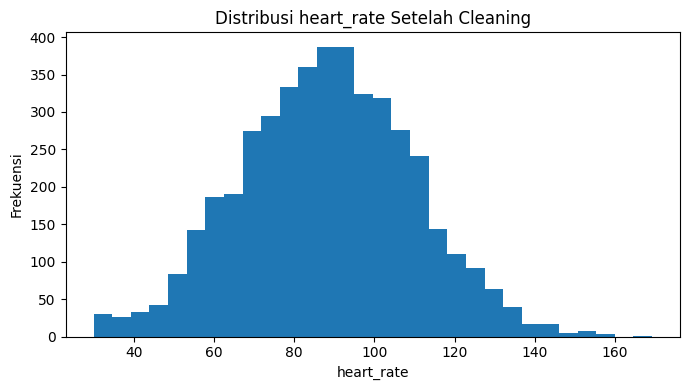

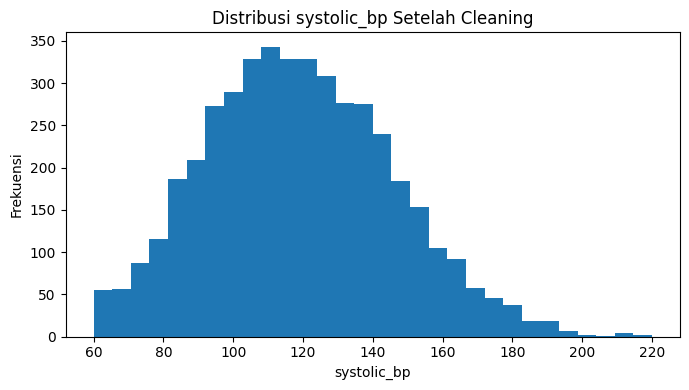

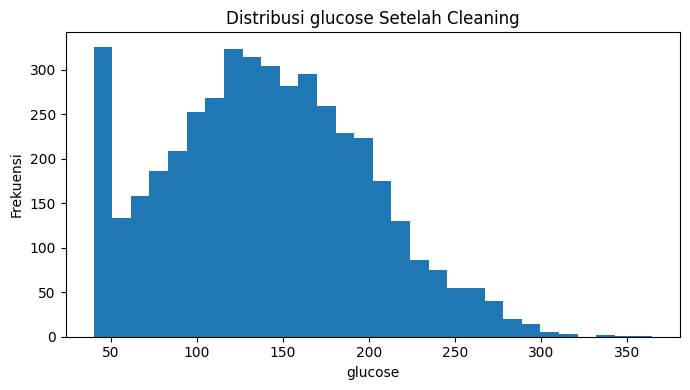

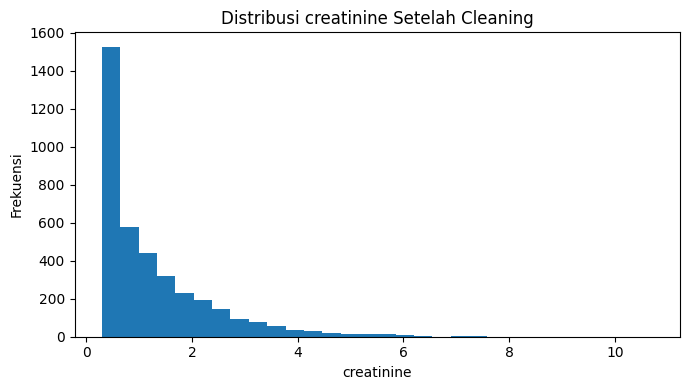

In [188]:
fitur_cleaning = [
    "heart_rate",
    "systolic_bp",
    "glucose",
    "creatinine"
]

for col in fitur_cleaning:

    plt.figure(
        figsize=(7, 4)
    )

    plt.hist(
        df_clean[col].dropna(),
        bins=30
    )

    plt.title(
        f"Distribusi {col} Setelah Cleaning"
    )

    plt.xlabel(col)
    plt.ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

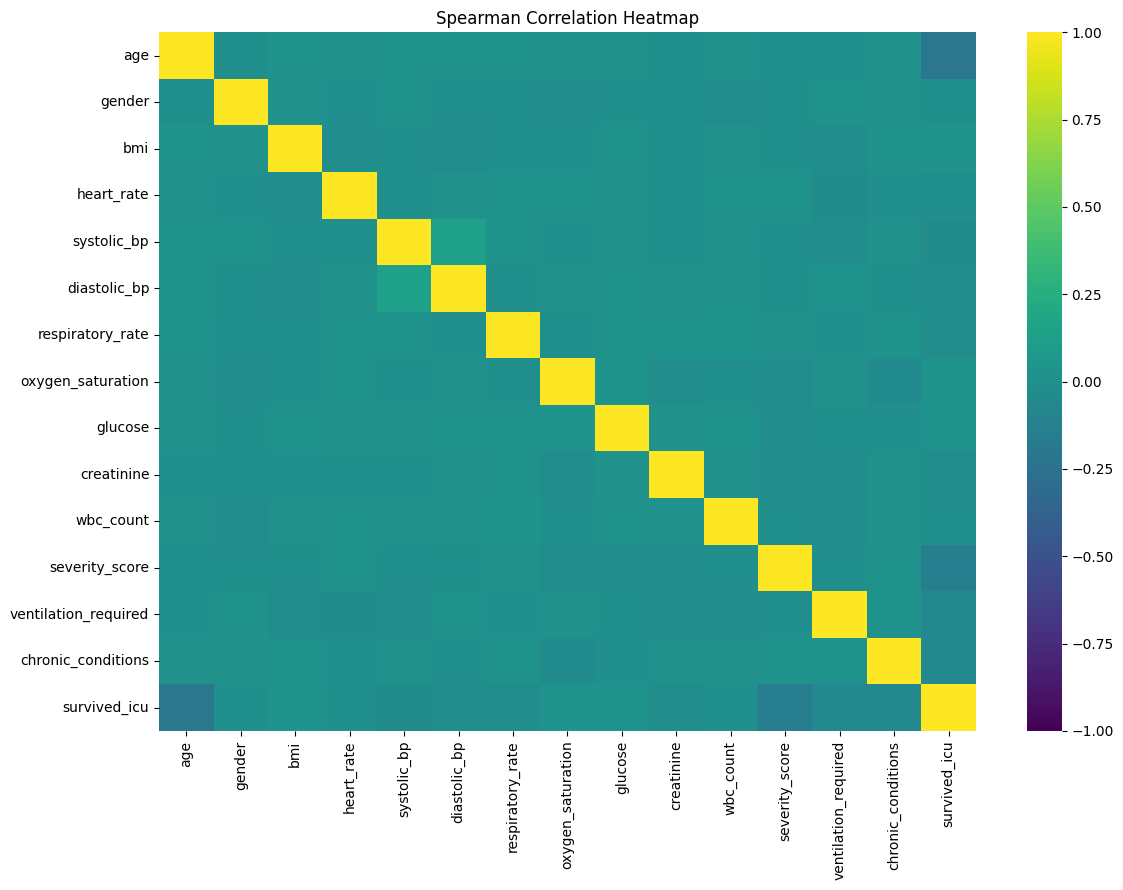

In [189]:
numeric_cols = df_clean.select_dtypes(
    include="number"
).columns

corr_spearman = (
    df_clean[numeric_cols]
    .corr(method="spearman")
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_spearman,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

plt.title(
    "Spearman Correlation Heatmap"
)

plt.tight_layout()
plt.show()

In [190]:
spearman_matrix_after = (
    df_clean[numeric_cols]
    .corr(method="spearman")
    .round(3)
)

display(spearman_matrix_after)

,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
age,1.000,-0.004,0.025,0.001,0.022,0.020,0.028,0.001,0.000,-0.014,0.007,-0.012,-0.010,0.002,-0.206
gender,-0.004,1.000,0.006,-0.013,0.021,-0.002,-0.012,-0.030,-0.003,-0.011,-0.019,-0.006,0.012,0.001,-0.006
bmi,0.025,0.006,1.000,-0.021,-0.003,-0.024,-0.011,-0.010,0.018,-0.011,0.005,-0.005,-0.024,0.018,0.028
heart_rate,0.001,-0.013,-0.021,1.000,-0.003,0.000,0.013,0.018,0.005,-0.001,0.023,0.016,-0.035,-0.015,-0.006
systolic_bp,0.022,0.021,-0.003,-0.003,1.000,0.131,0.012,-0.007,0.004,-0.006,0.002,-0.010,-0.028,0.004,-0.038
diastolic_bp,0.020,-0.002,-0.024,0.000,0.131,1.000,-0.002,0.004,0.009,0.004,0.006,-0.002,0.015,-0.003,-0.031
respiratory_rate,0.028,-0.012,-0.011,0.013,0.012,-0.002,1.000,-0.003,0.011,0.009,0.036,0.008,-0.008,0.017,-0.018
oxygen_saturation,0.001,-0.030,-0.010,0.018,-0.007,0.004,-0.003,1.000,0.037,-0.029,-0.014,-0.016,0.001,-0.046,0.031
glucose,0.000,-0.003,0.018,0.005,0.004,0.009,0.011,0.037,1.000,0.000,0.013,-0.016,-0.007,-0.015,0.013
creatinine,-0.014,-0.011,-0.011,-0.001,-0.006,0.004,0.009,-0.029,0.000,1.000,0.004,-0.019,-0.019,0.005,-0.028


In [191]:
target = "survived_icu"

corr_target = (
    corr_spearman[target]
    .drop(target)
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    corr_target
    .to_frame("Spearman_Correlation")
    .round(3)
)

,Spearman_Correlation
age,-0.206
severity_score,-0.153
ventilation_required,-0.062
chronic_conditions,-0.057
systolic_bp,-0.038
oxygen_saturation,0.031
diastolic_bp,-0.031
bmi,0.028
creatinine,-0.028
respiratory_rate,-0.018


In [192]:
df_clean

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_04779,18,1,31.0,68.0,115.4,30.0,13.0,89.8,44.8,0.30,1.03,18,1,5,1
1,ICU_00351,88,0,53.0,66.2,100.2,45.0,26.5,93.9,205.0,1.33,1.00,0,0,0,1
2,ICU_05145,64,0,32.6,54.8,107.0,68.6,24.2,93.8,85.6,1.39,1.73,17,0,2,1
3,ICU_00750,45,0,26.3,71.9,113.9,63.1,15.1,92.5,211.6,0.45,3.84,1,0,1,1
4,ICU_05211,42,1,44.5,135.3,150.9,95.7,20.2,100.0,148.8,0.80,16.42,21,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4517,ICU_DUP_0019,47,1,20.7,96.9,131.2,64.4,25.6,98.6,118.1,0.37,13.33,9,0,1,1
4518,ICU_DUP_0036,61,0,20.7,75.5,105.3,74.9,10.3,91.6,98.7,2.21,1.07,5,1,0,1
4519,ICU_DUP_0051,94,1,NaN,99.2,155.6,60.9,NaN,NaN,285.7,NaN,NaN,11,1,2,0
4520,ICU_DUP_0023,93,0,27.8,74.4,146.5,78.6,30.5,93.7,150.9,1.19,NaN,21,0,3,0


In [193]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4430.0,61.360722,17.167139,18.0,50.00,62.00,73.000,95.00
gender,4430.0,0.534312,0.498878,0.0,0.00,1.00,1.000,1.00
bmi,3822.0,26.997907,7.520964,9.0,21.60,26.40,31.700,57.00
heart_rate,4430.0,88.177088,21.458658,30.0,73.50,88.40,102.775,169.20
systolic_bp,4430.0,119.040835,26.702655,60.0,99.50,117.70,137.200,220.00
diastolic_bp,4430.0,70.815237,16.506411,30.0,59.80,71.00,81.900,130.00
respiratory_rate,3867.0,18.069382,5.891396,6.0,13.90,18.00,22.100,37.30
oxygen_saturation,3840.0,94.577995,4.388419,78.4,91.70,95.00,98.400,100.00
glucose,4430.0,140.704831,58.375889,40.0,98.90,139.35,181.000,364.70
creatinine,3804.0,1.238680,1.145799,0.3,0.36,0.87,1.670,10.71
